# Fall Detection — Webcam Inference (Jetson Nano, In-Notebook Display)

Real-time fall detection from a USB webcam, with the annotated video stream rendered **directly inside the Jupyter notebook** (no desktop GUI required).

The display uses the standard `show_array` + `clear_output(wait=True)` pattern: each annotated frame is JPEG-encoded, pushed via `IPython.display`, and the previous frame is cleared once the next one is ready (`wait=True` prevents flicker).

```
USB camera → MoveNet (TRT FP16) → 54-d features → 30-frame deque
           → BiGRU (CPU) → fall_prob → rule fusion → debounce → alarm
           → JPEG-encode and stream into the notebook output area
```

## Run order

1. **Cell 1** — Configuration.
2. **Cell 2** — Load TensorRT MoveNet + BiGRU.
3. **Cell 3** — Helpers (rules, overlay, `show_array`, run loop).
4. **Cell 4** — Open webcam and start inference (live stream appears below the cell).
5. **Cell 5** — *(Optional)* MoveNet sanity check on a single frame.

To stop the stream, hit the Jupyter ⏹ interrupt button — the cell catches `KeyboardInterrupt` cleanly.

## 1. Configuration

> Run `sudo nvpmodel -m 0 && sudo jetson_clocks` once before starting, otherwise the GPU clocks down and you lose ~30% FPS.

In [1]:
# ===== Configuration =================================================
# --- Model paths -----------------------------------------------------
ENGINE_PATH = 'movenet/output/pose_fp16.engine'
GRU_PATH    = 'models/fall_gru_v6.pth'

# --- Camera ----------------------------------------------------------
CAMERA_INDEX = 0
CAM_WIDTH    = 640
CAM_HEIGHT   = 480

# --- Output ----------------------------------------------------------
SAVE_OUT     = 'webcam_out.mp4'   # set to None to skip recording
JPEG_QUALITY = 70                 # 60-80 is sane; lower = faster encoding
DISPLAY_EVERY = 1                 # render every N processed frames (raise to 2 if Nano is slow)

# --- Alarm -----------------------------------------------------------
PROB_THRESHOLD = 0.88
ALARM_FRAMES   = 4
ALARM_HOLD     = 50

# --- Inference -------------------------------------------------------
INFERENCE_STRIDE = 1
SMOOTH_ALPHA     = 0.2
DRAW_KP_THR      = 0.2

# --- Rule fusion -----------------------------------------------------
RULE_ENABLE      = True
RULE_FORCE_ALARM = False
GRU_MIN_FOR_RULE = 0.60
RULE_BONUS_PROB  = 0.97

RULE_KP_SCORE_THR = 0.20
RULE_DROP_WINDOW  = 5
RULE_DROP_THR     = 0.75
RULE_ANGLE_THR    = 45.0
RULE_STILL_WINDOW = 12
RULE_STILL_SPEED  = 0.06
RULE_DROP_HOLD    = 12
RULE_MIN_SCALE    = 20.0
RULE_SUSTAINED_ANGLE_WINDOW = 20
RULE_SUSTAINED_ANGLE_THR    = 60.0

print('[config] ENGINE_PATH    =', ENGINE_PATH)
print('[config] GRU_PATH       =', GRU_PATH)
print('[config] SAVE_OUT       =', SAVE_OUT)
print('[config] PROB_THRESHOLD =', PROB_THRESHOLD)


[config] ENGINE_PATH    = movenet/output/pose_fp16.engine
[config] GRU_PATH       = models/fall_gru_v6.pth
[config] SAVE_OUT       = webcam_out.mp4
[config] PROB_THRESHOLD = 0.88


## 2. Load models

* **MoveNet** runs on the GPU via the TensorRT FP16 engine.
* **BiGRU** runs on the CPU — it has only 273K parameters, so CPU inference is ~15-20 ms and leaves the GPU free for MoveNet.

If TensorRT is not available the cell falls back to PyTorch MoveNet (much slower, dev machines only).

In [2]:
# ===== Load MoveNet (TRT) + BiGRU (CPU) ==============================
import os, sys, time, collections, io
import cv2
import numpy as np
import torch
from PIL import Image as PILImage
import IPython
from IPython.display import display

ROOT = os.getcwd()
sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.join(ROOT, 'movenet'))

from features    import KeypointFeatureExtractor, FEATURE_DIM
from fall_model  import FallDetectionGRU

SKELETON = [
    (0, 1), (0, 2), (1, 3), (2, 4),
    (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
    (5, 11), (6, 12), (11, 12),
    (11, 13), (13, 15), (12, 14), (14, 16),
]


def draw_keypoints_fallback(frame, keypoints, conf_thr=0.3,
                            color_pt=(0, 255, 0), color_line=(200, 200, 200)):
    vis = frame.copy()
    for (i, j) in SKELETON:
        if keypoints[i, 2] > conf_thr and keypoints[j, 2] > conf_thr:
            p1 = (int(keypoints[i, 0]), int(keypoints[i, 1]))
            p2 = (int(keypoints[j, 0]), int(keypoints[j, 1]))
            cv2.line(vis, p1, p2, color_line, 2)
    for k in range(17):
        x, y, s = keypoints[k]
        if s > conf_thr:
            cv2.circle(vis, (int(x), int(y)), 4, color_pt, -1)
    return vis


# --- MoveNet (TRT preferred) ----------------------------------------
movenet = None
try:
    from movenet.movenet_trt import MoveNetTRT, draw_keypoints as draw_keypoints_trt
    print('[INFO] Loading MoveNet TRT engine:', ENGINE_PATH)
    movenet = MoveNetTRT(ENGINE_PATH)
    draw_keypoints = draw_keypoints_trt
    print('[INFO] MoveNet backend: TensorRT FP16')
except Exception as e:
    print('[WARN] TensorRT unavailable ({}). Falling back to PyTorch MoveNet.'.format(e))
    from build_dataset import MoveNetTorch
    movenet_dir = os.path.join(ROOT, 'movenet')
    weights_rel = os.path.join('output', 'movenet.pth')
    weights_abs = os.path.join(movenet_dir, weights_rel)
    if not os.path.isfile(weights_abs):
        raise FileNotFoundError('Missing MoveNet weights: {}'.format(weights_abs))
    cwd = os.getcwd()
    os.chdir(movenet_dir)
    try:
        movenet = MoveNetTorch(weights_rel)
    finally:
        os.chdir(cwd)
    draw_keypoints = draw_keypoints_fallback
    print('[INFO] MoveNet backend: PyTorch (fallback)')

# --- BiGRU on CPU ---------------------------------------------------
print('[INFO] Loading BiGRU:', GRU_PATH)
gru, ckpt = FallDetectionGRU.load_from(GRU_PATH, map_location='cpu')
gru.eval()
SEQ_LEN = ckpt.get('seq_len', 30)
USE_EXTRA_FEATURES = (gru.input_dim == 54)

print('     seq_len     :', SEQ_LEN)
print('     params      : {:,}'.format(gru.num_parameters()))
print('     input_dim   :', gru.input_dim)
print('     extra_feats :', USE_EXTRA_FEATURES)
print('     prob_thr    : {:.3f}'.format(PROB_THRESHOLD))
if 'val_metrics' in ckpt:
    m = ckpt['val_metrics']
    print('     val F1      : {:.3f}  (P={:.3f}, R={:.3f})'.format(
        m.get('f1', 0), m.get('precision', 0), m.get('recall', 0)))


[INFO] Loading MoveNet TRT engine: movenet/output/pose_fp16.engine
[OK] MoveNetTRT loaded: movenet/output/pose_fp16.engine
     input : (1, 3, 192, 192)
     output: heatmap (1, 17, 48, 48)
     output: center (1, 1, 48, 48)
     output: regs (1, 34, 48, 48)
     output: offsets (1, 34, 48, 48)
[INFO] MoveNet backend: TensorRT FP16
[INFO] Loading BiGRU: models/fall_gru_v6.pth
     seq_len     : 30
     params      : 273,422
     input_dim   : 54
     extra_feats : True
     prob_thr    : 0.880
     val F1      : 0.816  (P=0.718, R=0.944)


## 3. Helpers — rules, overlay, run loop

The display follows the standard pattern from the course's `live_inference` utility:

```python
def show_array(a, fmt='jpeg'):
    f = io.BytesIO()
    PIL.Image.fromarray(a).save(f, fmt)
    display(IPython.display.Image(data=f.getvalue()))

# in the loop:
show_array(frame_rgb)
IPython.display.clear_output(wait=True)
```

`clear_output(wait=True)` doesn't wipe the cell immediately — it waits until the *next* display call lands, so the picture is replaced atomically and you don't see flicker.

OpenCV gives us BGR, but `PIL.Image.fromarray` (and the JupyterLab renderer) expect RGB, so the loop converts before showing.

In [3]:
# ===== Rule fusion + overlay + notebook-display run loop =============

KP_NOSE       = 0
KP_L_SHOULDER = 5
KP_R_SHOULDER = 6
KP_L_HIP      = 11
KP_R_HIP      = 12


def show_array(a, fmt='jpeg'):
    """Display an RGB ndarray inline in the Jupyter cell output."""
    f = io.BytesIO()
    PILImage.fromarray(a).save(f, fmt, quality=JPEG_QUALITY)
    display(IPython.display.Image(data=f.getvalue()))


def _center_from_kp(kp, idx_a, idx_b, score_thr):
    pa, pb = kp[idx_a], kp[idx_b]
    a_ok, b_ok = pa[2] >= score_thr, pb[2] >= score_thr
    if a_ok and b_ok:
        return (pa[:2] + pb[:2]) * 0.5
    if a_ok: return pa[:2]
    if b_ok: return pb[:2]
    return None


def _init_rule_state():
    return {
        'hip_hist'  : collections.deque(maxlen=RULE_DROP_WINDOW + 1),
        'scale_hist': collections.deque(maxlen=RULE_DROP_WINDOW + 1),
        'speed_hist': collections.deque(maxlen=RULE_STILL_WINDOW),
        'angle_hist': collections.deque(maxlen=RULE_SUSTAINED_ANGLE_WINDOW),
        'drop_timer': 0,
        'prev_hip'  : None,
    }


def _update_rule(kp, state):
    if not RULE_ENABLE:
        return False, {}

    hip      = _center_from_kp(kp, KP_L_HIP,      KP_R_HIP,      RULE_KP_SCORE_THR)
    shoulder = _center_from_kp(kp, KP_L_SHOULDER, KP_R_SHOULDER, RULE_KP_SCORE_THR)
    if hip is None or shoulder is None:
        state['drop_timer'] = max(state['drop_timer'] - 1, 0)
        state['prev_hip']   = None
        return False, {'reason': 'kp_missing'}

    scale = float(np.linalg.norm(shoulder - hip))
    if scale < RULE_MIN_SCALE:
        state['drop_timer'] = max(state['drop_timer'] - 1, 0)
        state['prev_hip']   = hip
        return False, {'reason': 'scale_small'}

    vec   = shoulder - hip
    angle = float(np.degrees(np.arctan2(abs(vec[0]), abs(vec[1]) + 1e-6)))

    state['hip_hist'].append(hip)
    state['scale_hist'].append(scale)
    state['angle_hist'].append(angle)

    drop_norm = None
    if len(state['hip_hist']) >= RULE_DROP_WINDOW + 1:
        dy        = float(state['hip_hist'][-1][1] - state['hip_hist'][0][1])
        scale_ref = max(float(np.mean(state['scale_hist'])), 1.0)
        drop_norm = dy / scale_ref

    drop_event  = (drop_norm is not None) and (drop_norm >= RULE_DROP_THR)
    angle_event = angle >= RULE_ANGLE_THR

    speed = 0.0
    if state['prev_hip'] is not None:
        speed = float(np.linalg.norm(hip - state['prev_hip'])) / max(scale, 1.0)
    state['prev_hip'] = hip
    state['speed_hist'].append(speed)
    still_event = (len(state['speed_hist']) >= RULE_STILL_WINDOW and
                   float(np.mean(state['speed_hist'])) <= RULE_STILL_SPEED)

    sustained_angle_event = (
        len(state['angle_hist']) >= RULE_SUSTAINED_ANGLE_WINDOW and
        float(np.mean(state['angle_hist'])) >= RULE_SUSTAINED_ANGLE_THR
    )

    if drop_event and angle_event:
        state['drop_timer'] = RULE_DROP_HOLD
    else:
        state['drop_timer'] = max(state['drop_timer'] - 1, 0)

    rule_flag = False
    if drop_event and angle_event:
        rule_flag = True
    if state['drop_timer'] > 0 and still_event and angle_event:
        rule_flag = True
    if sustained_angle_event and still_event:
        rule_flag = True

    return rule_flag, {
        'angle': angle, 'drop_norm': drop_norm or 0.0,
        'still': still_event, 'sustained': sustained_angle_event,
        'drop_timer': state['drop_timer'],
    }


def draw_overlay(frame, fall_prob, fused_prob, rule_active,
                 alarm_active, fps, seq_filled, seq_len):
    h, w = frame.shape[:2]

    if alarm_active:
        cv2.rectangle(frame, (0, 0), (w, 50), (0, 0, 200), -1)
        cv2.putText(frame, 'FALL DETECTED', (10, 35),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 3)

    bar_x, bar_y = 10, h - 30
    bar_w, bar_h = 220, 18
    cv2.rectangle(frame, (bar_x, bar_y),
                  (bar_x + bar_w, bar_y + bar_h), (50, 50, 50), -1)
    fill      = int(bar_w * float(fused_prob))
    bar_color = (0, 165, 255) if fused_prob < PROB_THRESHOLD else (0, 0, 255)
    cv2.rectangle(frame, (bar_x, bar_y),
                  (bar_x + fill, bar_y + bar_h), bar_color, -1)
    cv2.putText(frame, 'fall {:.2f} (gru {:.2f})'.format(fused_prob, fall_prob),
                (bar_x + 5, bar_y + 14),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    if rule_active:
        cv2.putText(frame, 'RULE', (10, 70),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

    cv2.putText(frame, '{:.1f} FPS'.format(fps), (w - 110, 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    cv2.putText(frame, 'buf {}/{}'.format(seq_filled, seq_len),
                (w - 110, h - 15),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
    return frame


def run_loop(cap, save_out=None, log_every=50):
    """
    Per-frame loop that streams the annotated frame back into the notebook
    via show_array() + clear_output(wait=True).
    Stop with the Jupyter interrupt button.
    """
    in_w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    in_h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    in_fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    print('[run] source: {}x{} @ {:.1f} fps'.format(in_w, in_h, in_fps))
    print('[run] press the Jupyter interrupt button to stop.')

    writer = None
    if save_out:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        writer = cv2.VideoWriter(save_out, fourcc, in_fps, (in_w, in_h))
        print('[run] recording to:', save_out)

    feat_ext = KeypointFeatureExtractor(smooth_alpha=SMOOTH_ALPHA,
                                        extra_features=USE_EXTRA_FEATURES)
    feat_ext.reset()
    feat_buffer = collections.deque(maxlen=SEQ_LEN)
    rule_state  = _init_rule_state()

    over_thr_count  = 0
    alarm_remaining = 0
    fall_prob       = 0.0
    fused_prob      = 0.0
    frame_idx       = 0
    alarm_count     = 0

    t_last     = time.time()
    fps_smooth = 0.0
    alpha_fps  = 0.1
    t_start    = time.time()

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                print('[run] stream ended at frame', frame_idx)
                break
            frame_idx += 1

            kp   = movenet.infer(frame)
            feat = feat_ext.extract(kp)
            feat_buffer.append(feat)

            if (len(feat_buffer) == SEQ_LEN and
                    frame_idx % INFERENCE_STRIDE == 0):
                seq = np.stack(list(feat_buffer), axis=0)
                with torch.no_grad():
                    x      = torch.from_numpy(seq).float().unsqueeze(0)
                    logits = gru(x)
                    probs  = torch.softmax(logits, dim=1)[0].numpy()
                fall_prob = float(probs[1])

            rule_active, _ = _update_rule(kp, rule_state)
            fused_prob = fall_prob
            if RULE_ENABLE and rule_active:
                if RULE_FORCE_ALARM or fall_prob >= GRU_MIN_FOR_RULE:
                    fused_prob = max(fall_prob, RULE_BONUS_PROB)

            if fused_prob >= PROB_THRESHOLD:
                over_thr_count += 1
            else:
                over_thr_count = 0
            if over_thr_count >= ALARM_FRAMES:
                alarm_remaining = ALARM_HOLD
                over_thr_count  = 0
                alarm_count    += 1
                # NOTE: don't print here -- it survives clear_output and pushes
                # the live image down the page. The alarm banner is drawn on the
                # frame itself, which is enough.

            if alarm_remaining > 0:
                alarm_remaining -= 1
            alarm_active = alarm_remaining > 0

            vis = draw_keypoints(frame, kp, conf_thr=DRAW_KP_THR)

            t_now    = time.time()
            dt       = max(t_now - t_last, 1e-6)
            cur_fps  = 1.0 / dt
            t_last   = t_now
            fps_smooth = ((1 - alpha_fps) * fps_smooth + alpha_fps * cur_fps
                          if fps_smooth > 0 else cur_fps)

            vis = draw_overlay(vis, fall_prob, fused_prob, rule_active,
                               alarm_active, fps_smooth,
                               len(feat_buffer), SEQ_LEN)

            if writer is not None:
                writer.write(vis)

            # Inline display: BGR -> RGB, then show_array + clear_output(wait=True)
            if frame_idx % DISPLAY_EVERY == 0:
                vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
                show_array(vis_rgb)
                IPython.display.clear_output(wait=True)

    except KeyboardInterrupt:
        print('[run] interrupted by user')
    finally:
        cap.release()
        if writer is not None:
            writer.release()
        elapsed = time.time() - t_start
        avg_fps = frame_idx / elapsed if elapsed > 0 else 0.0
        print('[run] done -- {} frames in {:.1f} s, avg {:.2f} FPS, {} alarms fired'.format(
            frame_idx, elapsed, avg_fps, alarm_count))


print('[ok] helpers ready')


[ok] helpers ready


## 4. Open webcam and run

Once you run this cell the live annotated stream will appear directly below it. To stop, click the **interrupt** button in Jupyter (⏹ on the toolbar, or `Kernel → Interrupt`).

### Display performance tips

* If the live stream looks choppy, raise `DISPLAY_EVERY` to 2 in Cell 1 (renders every other frame; processing still runs every frame).
* Lower `JPEG_QUALITY` to 50 for faster encode if your network/browser is the bottleneck (especially over SSH-forwarded Jupyter).
* `SAVE_OUT` keeps recording the full-rate annotated video to disk regardless of `DISPLAY_EVERY`.

In [4]:
# ===== Run on a live USB webcam =======================================
cap = cv2.VideoCapture(CAMERA_INDEX, cv2.CAP_V4L2)
if not cap.isOpened():
    cap = cv2.VideoCapture(CAMERA_INDEX)
if not cap.isOpened():
    raise RuntimeError('Could not open camera index {}'.format(CAMERA_INDEX))

cap.set(cv2.CAP_PROP_FOURCC,       cv2.VideoWriter_fourcc(*'MJPG'))
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  CAM_WIDTH)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, CAM_HEIGHT)
cap.set(cv2.CAP_PROP_BUFFERSIZE,   1)

run_loop(cap, save_out=SAVE_OUT)


[run] interrupted by user
[run] done -- 8941 frames in 1225.0 s, avg 7.30 FPS, 203 alarms fired


## 5. *(Optional)* MoveNet sanity check

Reads one frame from the webcam, runs MoveNet once, prints keypoint scores, and shows the annotated frame inline. Use this if Cell 4 produces no alarms or odd FPS — it tells you whether MoveNet itself is producing sensible keypoints.

A healthy frame of a person should show a score range roughly `[0.05, 0.85]` with mean ~0.3-0.5. If every score is below 0.1 the preprocessing is broken (most often: someone re-introduced letterbox padding or `/255` in `movenet_trt.py`).

frame shape : (480, 640, 3)
kp shape    : (17, 3)
score range : [0.007, 0.165]  mean=0.052
latency     : 128.4 ms (single frame)


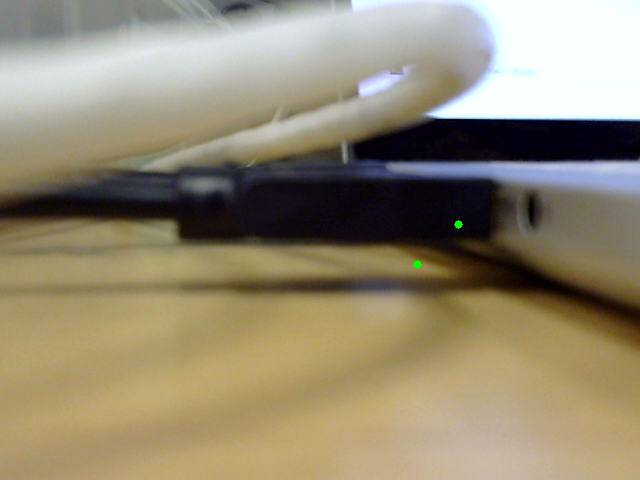

also saved -> debug_sanity.jpg


In [5]:
# ===== MoveNet single-frame sanity check ==============================
cap = cv2.VideoCapture(CAMERA_INDEX, cv2.CAP_V4L2)
if not cap.isOpened():
    cap = cv2.VideoCapture(CAMERA_INDEX)
cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*'MJPG'))
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  CAM_WIDTH)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, CAM_HEIGHT)
# Discard a few frames; first ones from many webcams are dark / auto-exposing.
for _ in range(5):
    cap.read()

ret, frame = cap.read()
cap.release()
assert ret, 'Failed to read a frame from camera'

t0 = time.time()
kp = movenet.infer(frame)
dt = (time.time() - t0) * 1000.0

print('frame shape :', frame.shape)
print('kp shape    :', kp.shape)
print('score range : [{:.3f}, {:.3f}]  mean={:.3f}'.format(
    kp[:, 2].min(), kp[:, 2].max(), kp[:, 2].mean()))
print('latency     : {:.1f} ms (single frame)'.format(dt))

vis = draw_keypoints(frame, kp, conf_thr=0.1)
vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
show_array(vis_rgb)

cv2.imwrite('debug_sanity.jpg', vis)
print('also saved -> debug_sanity.jpg')


## Troubleshooting

| Symptom | Likely cause |
|---|---|
| `Could not open camera index 0` | Camera not at `/dev/video0`. Try `CAMERA_INDEX = 1`, or check `ls /dev/video*`. |
| Display window flickers | You shouldn't see flicker because `clear_output(wait=True)` defers the clear. If you do, double-check Cell 3 was run cleanly. |
| Stream very choppy / FPS counter low | Network bandwidth (when accessing Jupyter remotely) or JPEG encoding. Lower `JPEG_QUALITY` to 50 and/or raise `DISPLAY_EVERY` to 2. |
| FPS stuck at 7-10 | Camera is in YUYV. Cell 4 forces MJPG; if it still fails, the camera doesn't support MJPG. |
| `[ALARM]` fires constantly while standing | `PROB_THRESHOLD` too low. Try 0.92. |
| Misses obvious falls | `PROB_THRESHOLD` too high. Try 0.85. Run Cell 5 first — if MoveNet scores are < 0.1 fix that before tuning. |
| `ImportError: tensorrt` / `pycuda` | JetPack not properly set up; cell falls back to PyTorch MoveNet (~2 FPS). |